# PR08 · Surfaces are meshes, not thin voxel masks

<!-- paper-first -->
### Research question

**Reading:** [PP03](../../curriculum/papers/processing.md#pp03). Review the assigned figure or result before starting the lesson.

**Question:** Which surface or topology claims cannot be established from a voxel-segmentation score alone?

Record a prediction, a source location, and one point you want this lesson to clarify. Ask your AI tutor to distinguish the paper’s evidence from its interpretation.
<!-- /paper-first -->

**Format:** 75–100 minutes for this lesson and its small executable lab, followed by the explicitly labeled upstream practice. Run this notebook from a fresh kernel, top to bottom. Core data are synthetic. Software: NumPy, SciPy, Matplotlib; extra imports are stated in code. This is one stage of a longer processing course, not a replacement for supervised research training.

## Learning objectives

- Identify vertices, faces, adjacency and coordinate units.
- Check a simple mesh for an open boundary.
- Explain why surface correspondence and anatomical boundary placement matter for thickness.

## Understand the operation

A cortical surface is represented by vertices joined into faces. Geometry gives their positions; topology gives their neighborhood relationships. A surface can be inflated for visualization while retaining its vertex correspondence, so a value attached to a vertex can remain meaningful even when the displayed coordinates change. The inflated picture is not a literal anatomical boundary. Two nearby points across a sulcus can be far apart along the sheet, making volumetric proximity different from surface adjacency.

A reconstructed white surface and pial surface represent different anatomical boundaries. Thickness estimation involves those boundaries and a method for correspondence or distance; it is not generally equivalent to subtracting voxel indices or pairing arbitrary vertex rows. Dura mistaken for pial surface can enlarge a measurement, and white-matter defects can displace the inner boundary. Registration to a common surface uses its own correspondence machinery rather than merely matching array dimensions.

We use a closed octahedron as a transparent mesh. Its Euler characteristic is V−E+F=2. Removing one triangular face creates a boundary and changes the characteristic. That is a diagnostic of this known topology, not a universal automatic correction rule for every mesh. A concentric outer octahedron provides intentionally simple paired radial distances. Shuffling its vertex correspondence preserves the coordinate set and vertex count but corrupts those distances. This isolates an error that looks innocuous in a table of coordinates.

## Transformation contract

**Input:** vertices in millimeters and triangular face indices. **Output:** edge counts, Euler characteristic and paired distances. **Preserved when deleting a face:** coordinates, but not topology. **Lost when correspondence is shuffled:** meaningful pairing. **Not claimed:** FreeSurfer cortical reconstruction or its thickness algorithm.


## Read the actual course material

- [FreeSurfer: volume/surface, ROI and longitudinal workshop](https://surfer.nmr.mgh.harvard.edu/fswiki/FsTutorial). Official workshop; linked only.
- [fMRIPrep: pipeline details](https://fmriprep.org/en/stable/workflows.html). Official project documentation; linked only.

Read the named topic alongside this lesson; compare its real-image assumptions with our controlled example. These notebooks use original explanations and original code, not copied upstream passages. The source chapter is the place to continue to a complete real-tool practical. External software and downloaded datasets are not silently run by this notebook.


## Predict, then ask your AI assistant

Use Goose with your installed Ollama model, or ChatGPT. The model is a tutor and code author; the local Python runtime performs these calculations. Paste:

> Count mesh edges and identify boundary edges from face incidence. Compare the correct radial pairing with a vertex permutation. Explain why the same coordinate set and vertex count do not prove valid surface correspondence. Return at most 20 executable lines per cell, show units and array shapes, and preserve the original. Explain the prediction before running. If an assertion fails, diagnose the disagreement rather than deleting the check.

Write your prediction before executing the reference cells below.


In [1]:
import numpy as np
vertices=np.array([[1,0,0],[-1,0,0],[0,1,0],[0,-1,0],[0,0,1],[0,0,-1.]])*10
faces=np.array([[0,2,4],[2,1,4],[1,3,4],[3,0,4],[2,0,5],[1,2,5],[3,1,5],[0,3,5]])
def topology(f):
    edges=np.sort(np.vstack([f[:,[0,1]],f[:,[1,2]],f[:,[2,0]]]),axis=1)
    unique,counts=np.unique(edges,axis=0,return_counts=True)
    return len(vertices)-len(unique)+len(f),np.count_nonzero(counts==1)
print('closed / punctured (Euler,boundary edges):',topology(faces),topology(faces[:-1]))
assert topology(faces)==(2,0) and topology(faces[:-1])==(1,3)
outer=vertices*1.2
paired=np.linalg.norm(outer-vertices,axis=1)
wrong=np.linalg.norm(outer[[1,0,2,3,4,5]]-vertices,axis=1)
assert np.allclose(paired,2) and wrong.max()>20
print('paired / shuffled distances mm:',paired,wrong)


closed / punctured (Euler,boundary edges): (2, np.int64(0)) (1, np.int64(3))
paired / shuffled distances mm: [2. 2. 2. 2. 2. 2.] [22. 22.  2.  2.  2.  2.]


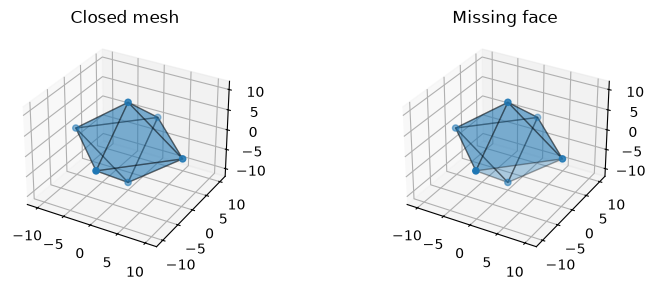

In [2]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
fig=plt.figure(figsize=(8,3))
for index,f,title in [(1,faces,'Closed mesh'),(2,faces[:-1],'Missing face')]:
    ax=fig.add_subplot(1,2,index,projection='3d')
    ax.add_collection3d(Poly3DCollection(vertices[f],alpha=.35,edgecolor='black'))
    ax.scatter(*vertices.T); ax.set(xlim=(-12,12),ylim=(-12,12),zlim=(-12,12),title=title)
plt.tight_layout(); plt.show()


## Check and explain

The closed mesh has characteristic2 and no boundary edges; the punctured mesh has characteristic1 and three boundary edges. Correct toy paired distances are2mm; swapping opposite vertices creates22mm distances. All these checks concern the constructed mesh.

## Deliberately wrong method

Taking an arbitrary row-by-row distance between unrelated meshes produces a number without established anatomical meaning. Forcing every real mesh to characteristic2 by deleting or adding faces is not a justified repair. Inspect the intended topology and reconstruction method.

## Transfer to an actual dataset or tool — guided assignment

Use the FreeSurfer workshop’s Introduction to Output, ROI Analysis and Troubleshooting tutorials with its separately supplied processed subject. In Freeview, inspect white/pial boundaries against the anatomy in multiple planes, then compare anatomical and inflated surface displays. Record vertex count, hemisphere, coordinate convention and parcellation. Name one potential pial/white-boundary error and its likely effect on a measurement. This requires FreeSurfer outputs; the octahedron is not a substitute.

**Submit:** a transformation card, one labeled figure or numerical result, the failed-method diagnosis, and the upstream-practice evidence. If the external exercise has not been run, mark it **not executed** and state the missing software/data; do not convert a proposed command into a claimed result.

## Exit questions and answer key

1. What survives inflation if vertex correspondence is retained? **Answer:** topology and vertex-associated measurements, though displayed coordinates change.
2. Why can two matching vertex counts still give wrong thickness? **Answer:** the rows may not be corresponding locations, and the anatomical boundaries or distance definition may be wrong.


### Return to the research question

Revisit [PP03](../../curriculum/papers/processing.md#pp03) and your initial prediction. In your [evidence ledger](../../curriculum/coursework/EVIDENCE_LEDGER.md):

1. Cite one output or diagnostic from this lesson and explain the transformation it demonstrates.
2. Revise one claim or question from the paper, with a figure or section locator. Which part of the published result remains open after this exercise?
3. Ask AI to propose a next check. Accept, revise or reject it with a scientific reason. Then explain your decision aloud without reading the AI response.

Include this entry in the A2 portfolio when relevant.
